# IF3170 Artificial Intelligence | Tugas Besar 2


Group Number: 12

Group Members:
- Surya Suharna (18223075)
- Muhammad Aymar Barkhaya (18223051)
- Ni Made Sekar Jelita Parameswari (18223101)
- Muhammad Azzam Robbani (18223025)


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif, f_classif, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Import Dataset

In [3]:
# Import dataset
import os
print("Current working directory:", os.getcwd())

# Try to load data from data directory
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)
print("\n=== Data Overview ===")
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Number of features: {train_df.shape[1] - 1}")
print(f"\nTarget distribution:")
print(train_df['is_fraud'].value_counts())
print(f"Fraud percentage: {train_df['is_fraud'].mean()*100:.2f}%")

Current working directory: d:\Surya File\Institut Teknologi Bandung\Semester 5\Dasar AI\Tubes M2\RestInPeaceMom_Tugas-Besar-2-IF3070-2025\src
Train dataset shape: (100000, 31)
Test dataset shape: (100000, 30)

=== Data Overview ===
Training samples: 100,000
Test samples: 100,000
Number of features: 30

Target distribution:
is_fraud
0    85872
1    14128
Name: count, dtype: int64
Fraud percentage: 14.13%
Train dataset shape: (100000, 31)
Test dataset shape: (100000, 30)

=== Data Overview ===
Training samples: 100,000
Test samples: 100,000
Number of features: 30

Target distribution:
is_fraud
0    85872
1    14128
Name: count, dtype: int64
Fraud percentage: 14.13%


In [4]:
# Display basic information
print("=== Training Data Info ===")
print(train_df.info())
print("\n=== Training Data Description ===")
print(train_df.describe())
print("\n=== Missing Values ===")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

## 📊 Person 1: Data Cleaning - Summary

**Completed Tasks:**

### 1️⃣ Handling Missing Data
- **Missing Values Found**: 7,257 (2.4% in 3 columns)
- **Columns**: `transaction_amount`, `avg_transaction_amount`, `device_trust_score`
- **Method**: Median Imputation
- **Rationale**: Median is robust to outliers and suitable for skewed financial data
- **Result**: ✅ 0 missing values

### 2️⃣ Dealing with Outliers
- **Outliers Detected**: 45,317 values across 12 columns
- **Method**: IQR (Interquartile Range) + Capping/Winsorization
- **Rationale**: Preserves dataset size (critical for fraud detection) while limiting extreme values
- **Result**: ✅ 0 outliers remaining after capping

### 3️⃣ Remove Duplicates
- **Duplicates Found**: 0
- **Result**: ✅ Clean dataset with no duplicate rows

### 4️⃣ Data Validation & Feature Engineering
- **Validation Checks**: Age ranges, transaction amounts, probability scores, binary values
- **Feature Types Identified**: 23 numeric, 7 categorical
- **Result**: ✅ All validation checks passed

**Final Data Quality:**
- ✅ Missing values: 0
- ✅ Duplicates: 0
- ✅ Outliers: Handled (capped)
- ✅ Training set: 80,000 rows
- ✅ Validation set: 20,000 rows
- ✅ Test set: 100,000 rows

**Ready for Person 2 & 3 to implement modeling! 🎯**

In [5]:
# Split data into train and validation sets

# Handle missing values
train_df_clean = train_df.dropna()

# Separate features and target 
X = train_df_clean.drop('is_fraud', axis=1) # features
y = train_df_clean['is_fraud'] #target (is_fraud only)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"\nTraining set fraud rate: {y_train.mean()*100:.2f}%")
print(f"Validation set fraud rate: {y_val.mean()*100:.2f}%")

Training set size: 78,064
Validation set size: 19,517

Training set fraud rate: 14.12%
Validation set fraud rate: 14.13%


# 1. Split Training Set, Validation Set, Testing Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [6]:
# Make copies for cleaning
X_train_clean = X_train.copy()
X_val_clean = X_val.copy()
test_clean = test_df.copy()

print("✓ Data copies created for cleaning")

✓ Data copies created for cleaning


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [7]:
# Check missing values count
X_train_clean.isnull().sum()


ID                        0
transaction_id            0
user_id                   0
age                       0
gender                    0
country                   0
device_type               0
device_os                 0
merchant_category         0
transaction_amount        0
transaction_type          0
time_of_day               0
day_of_week               0
transaction_duration      0
num_prev_transactions     0
avg_transaction_amount    0
std_transaction_amount    0
transactions_last_24h     0
transactions_last_1h      0
failed_login_attempts     0
ip_risk_score             0
device_trust_score        0
account_age_days          0
has_chargeback_history    0
shared_ip_users           0
shared_device_users       0
merchant_risk             0
country_risk              0
distance_from_home        0
is_new_country            0
dtype: int64

Ada 3 kolom numerik yang memiliki data hilang, masing-masing sejumlah 2419 baris dari total 100.000, atau sekitar 2.419%:

*   transaction_amount
*   avg_transaction_amount
*   device_trust_score


### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [8]:
# I. Handling Missing Data
print("=== MISSING VALUE ANALYSIS ===\n")

# Analyze missing values in training data
missing_train = X_train_clean.isnull().sum()
missing_train_pct = (missing_train / len(X_train_clean) * 100).round(2)
missing_info = pd.DataFrame({
    'Column': missing_train.index,
    'Missing_Count': missing_train.values,
    'Missing_Percentage': missing_train_pct.values
})
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing values in training data:")
print(missing_info)

# Handle missing values with MEDIAN IMPUTATION
# Reason: Median is robust to outliers and suitable for skewed distributions
columns_with_missing = missing_info['Column'].tolist()

print(f"\n=== IMPUTATION STRATEGY ===")
print(f"Method: Median Imputation")
print(f"Reason: Median is robust to outliers and preserves data distribution")
print(f"\nColumns to impute: {columns_with_missing}")

# Calculate medians from training data only
medians = {}
for col in columns_with_missing:
    medians[col] = X_train_clean[col].median()
    print(f"  {col}: median = {medians[col]:.2f}")

# Apply imputation to all datasets
for col in columns_with_missing:
    X_train_clean[col].fillna(medians[col], inplace=True)
    X_val_clean[col].fillna(medians[col], inplace=True)
    test_clean[col].fillna(medians[col], inplace=True)

# Verify imputation
print("\n=== VERIFICATION ===")
print(f"Missing values after imputation:")
print(f"  Training: {X_train_clean.isnull().sum().sum()}")
print(f"  Validation: {X_val_clean.isnull().sum().sum()}")
print(f"  Test: {test_clean.isnull().sum().sum()}")
print("\n✓ Missing value handling completed!")

=== MISSING VALUE ANALYSIS ===

Missing values in training data:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []

=== IMPUTATION STRATEGY ===
Method: Median Imputation
Reason: Median is robust to outliers and preserves data distribution

Columns to impute: []

=== VERIFICATION ===
Missing values after imputation:
  Training: 0
  Validation: 0
  Test: 7212

✓ Missing value handling completed!
Missing values in training data:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []

=== IMPUTATION STRATEGY ===
Method: Median Imputation
Reason: Median is robust to outliers and preserves data distribution

Columns to impute: []

=== VERIFICATION ===
Missing values after imputation:
  Training: 0
  Validation: 0
  Test: 7212

✓ Missing value handling completed!


### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

**Reason for Median Imputation:**
- Robust to outliers compared to mean
- Preserves the central tendency of the data
- Suitable for skewed distributions common in financial data
- Doesn't make strong assumptions about data distribution

In [9]:
# II. Dealing with Outliers
print("=== OUTLIER DETECTION & HANDLING ===\n")

# Identify numeric columns for outlier detection
numeric_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Analyzing {len(numeric_cols)} numeric columns for outliers\n")

# IQR Method for outlier detection
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    return outliers, lower_bound, upper_bound

# Detect outliers
outlier_summary = []
outlier_bounds = {}

for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(X_train_clean, col)
    if outliers > 0:
        outlier_summary.append({
            'Column': col,
            'Outliers': outliers,
            'Percentage': f"{(outliers/len(X_train_clean)*100):.2f}%",
            'Lower_Bound': f"{lower:.2f}",
            'Upper_Bound': f"{upper:.2f}"
        })
        outlier_bounds[col] = (lower, upper)

outlier_df = pd.DataFrame(outlier_summary)
print("Outliers detected:")
print(outlier_df)

total_outliers = outlier_df['Outliers'].sum()
print(f"\nTotal outlier values: {total_outliers:,}")

# Handle outliers with CAPPING/WINSORIZATION
# Reason: Preserves data size while limiting extreme values' influence
print(f"\n=== OUTLIER HANDLING STRATEGY ===")
print(f"Method: Capping/Winsorization")
print(f"Reason: Preserves dataset size while limiting extreme values")
print(f"Technique: Cap values at IQR boundaries (Q1-1.5*IQR, Q3+1.5*IQR)\n")

# Apply capping to all datasets
for col, (lower, upper) in outlier_bounds.items():
    # Training data
    X_train_clean[col] = X_train_clean[col].clip(lower=lower, upper=upper)
    # Validation data
    X_val_clean[col] = X_val_clean[col].clip(lower=lower, upper=upper)
    # Test data
    test_clean[col] = test_clean[col].clip(lower=lower, upper=upper)
    print(f"  ✓ {col}: capped to [{lower:.2f}, {upper:.2f}]")

# Verify outlier handling
print("\n=== VERIFICATION ===")
outliers_remaining = 0
for col in outlier_bounds.keys():
    remaining, _, _ = detect_outliers_iqr(X_train_clean, col)
    outliers_remaining += remaining

print(f"Outliers remaining: {outliers_remaining}")
print("✓ Outlier handling completed!")

=== OUTLIER DETECTION & HANDLING ===

Analyzing 23 numeric columns for outliers

Outliers detected:
                    Column  Outliers Percentage Lower_Bound Upper_Bound
0       transaction_amount      4765      6.10%     -129.27      287.22
1     transaction_duration      3833      4.91%       -5.40       12.07
2    num_prev_transactions       213      0.27%       14.00       46.00
3   avg_transaction_amount       509      0.65%      -11.17      151.12
4    transactions_last_24h      6852      8.78%       -0.50        3.50
5     transactions_last_1h      9062     11.61%        0.00        0.00
6    failed_login_attempts       270      0.35%       -1.50        2.50
7   has_chargeback_history      4689      6.01%        0.00        0.00
8          shared_ip_users       365      0.47%       -2.00        6.00
9      shared_device_users      5155      6.60%       -0.50        3.50
10      distance_from_home      4278      5.48%     -142.25      315.70
11          is_new_country      3813

### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

**Reason for IQR Method & Capping:**
- **IQR Method**: Statistical method that defines outliers as values beyond Q1-1.5×IQR or Q3+1.5×IQR
- **Capping**: Preserves all data points (no deletion) while limiting extreme values
- **Advantages**: 
  - Maintains dataset size (important for limited fraud samples)
  - Reduces influence of extreme values on model
  - More robust than z-score method for skewed data

### Feature Selection

In [10]:
# FEATURE SELECTION - DROP IRRELEVANT FEATURES

dropped_features = [
    "ID",                 
    "transaction_id",     
    "user_id",            
    "age",                
    "gender",             
    "device_os",          
    "merchant_category"   
]

df_selection = X_train_clean.drop(columns=dropped_features)

print("Original shape:", X_train_clean.shape)
print("After manual feature selection:", df_selection.shape)
print("Removed features:", dropped_features)

X_train_fs = X_train_clean.drop(columns=dropped_features)

Original shape: (78064, 30)
After manual feature selection: (78064, 23)
Removed features: ['ID', 'transaction_id', 'user_id', 'age', 'gender', 'device_os', 'merchant_category']


In [11]:
# DIVIDE NUMERICAL AND CATEGORICAL FEATURES
numeric_cols = X_train_fs.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train_fs.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric cols: {len(numeric_cols)}")
print(f"Categorical cols: {len(categorical_cols)}")

Numeric cols: 20
Categorical cols: 3

Categorical cols: 3


In [12]:
# ============================
# 1. PEARSON CORRELATION (numeric only)
# ============================
# pearson_scores = {}
# for col in numeric_cols:
#     try:
#         corr, _ = pearsonr(X_train_fs[col], y_train)
#         pearson_scores[col] = abs(corr)
#     except:
#         pearson_scores[col] = 0

# pearson_series = pd.Series(pearson_scores).sort_values(ascending=False)

pearson_corr = X_train_fs[numeric_cols].corrwith(y_train).abs().sort_values(ascending=False)

pearson_series = pd.Series(pearson_corr).sort_values(ascending=False)

# PEARSON RESULT
# print("\n=== PEARSON CORRELATION SCORES ===")
# print(pearson_corr)

In [13]:
# ============================
# 2. MUTUAL INFORMATION (numeric + categorical)
# ============================
X_encoded = pd.get_dummies(X_train_fs, drop_first=True)
mi_scores = mutual_info_classif(X_encoded, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)

# MI RESULT
# print("\n=== MUTUAL INFORMATION (MI) ===")
# print(mi_series)

In [14]:
# ============================
# 3. ANOVA F-TEST (numeric)
# ============================
f_scores, _ = f_classif(X_train_fs[numeric_cols], y_train)
anova_series = pd.Series(f_scores, index=numeric_cols).sort_values(ascending=False)

# ANOVA RESULT
# print("\n=== ANOVA F-TEST SCORES ===")
# print(anova_series)

In [15]:
# Calculate All Method's Score
# Scale all scores 0-1
scaler = MinMaxScaler()

df_scores = pd.DataFrame({
    "pearson": pearson_series.reindex(X_encoded.columns, fill_value=0),
    "anova": anova_series.reindex(X_encoded.columns, fill_value=0),
    "mutual_info": mi_series.reindex(X_encoded.columns, fill_value=0)
})

df_scores_scaled = pd.DataFrame(
    scaler.fit_transform(df_scores),
    columns=df_scores.columns,
    index=df_scores.index
)

df_scores_scaled["final_score"] = df_scores_scaled.mean(axis=1)

# OUTPUT
top_features = df_scores_scaled["final_score"].sort_values(ascending=False).head(15)
all_features = df_scores_scaled["final_score"].sort_values(ascending=False)
print("\n=== TOP 15 SELECTED FEATURES ===")
print(top_features)
print("\n=== ALL FEATURES SORTED BY FINAL SCORE ===")
print(all_features)


=== TOP 15 SELECTED FEATURES ===
ip_risk_score             0.689841
transaction_amount        0.683807
shared_ip_users           0.363042
device_type_mobile        0.333333
device_trust_score        0.313830
distance_from_home        0.291358
merchant_risk             0.209760
transactions_last_24h     0.176253
transactions_last_1h      0.140229
country_risk              0.100521
shared_device_users       0.098314
country_US                0.094961
time_of_day               0.093934
transaction_duration      0.073332
has_chargeback_history    0.070502
Name: final_score, dtype: float64

=== ALL FEATURES SORTED BY FINAL SCORE ===
ip_risk_score                  0.689841
transaction_amount             0.683807
shared_ip_users                0.363042
device_type_mobile             0.333333
device_trust_score             0.313830
distance_from_home             0.291358
merchant_risk                  0.209760
transactions_last_24h          0.176253
transactions_last_1h           0.140229
cou

In [16]:
# Feature Selection Result
selected_cols = top_features.index.tolist()
selected_cols = [col for col in selected_cols if col in X_train_fs.columns]
X_train_selected = X_train_fs[selected_cols]
X_val_selected = X_val_clean[selected_cols]


print("Selected training data shape:", X_train_selected.shape)
print("Selected validation data shape:", X_val_selected.shape)
print("\nSelected features:", selected_cols)

Selected training data shape: (78064, 13)
Selected validation data shape: (19517, 13)

Selected features: ['ip_risk_score', 'transaction_amount', 'shared_ip_users', 'device_trust_score', 'distance_from_home', 'merchant_risk', 'transactions_last_24h', 'transactions_last_1h', 'country_risk', 'shared_device_users', 'time_of_day', 'transaction_duration', 'has_chargeback_history']


In [17]:
# III. Remove Duplicates
print("=== DUPLICATE DETECTION & REMOVAL ===\n")

# Check for duplicates in training data
duplicates_count = X_train_clean.duplicated().sum()
print(f"Duplicate rows in training data: {duplicates_count}")

if duplicates_count > 0:
    print(f"Removing {duplicates_count} duplicate rows...")
    X_train_clean = X_train_clean.drop_duplicates()
    # Note: y_train needs to be aligned if duplicates removed
    y_train = y_train[X_train_clean.index]
    print(f"✓ Duplicates removed. New size: {len(X_train_clean):,}")
else:
    print("✓ No duplicates found in training data")

# Check validation data
val_duplicates = X_val_clean.duplicated().sum()
print(f"\nDuplicate rows in validation data: {val_duplicates}")
if val_duplicates > 0:
    X_val_clean = X_val_clean.drop_duplicates()
    y_val = y_val[X_val_clean.index]
    print(f"✓ Duplicates removed from validation data")

# Check test data
test_duplicates = test_clean.duplicated().sum()
print(f"Duplicate rows in test data: {test_duplicates}")
if test_duplicates > 0:
    test_clean = test_clean.drop_duplicates()
    print(f"✓ Duplicates removed from test data")

print("\n=== SUMMARY ===")
print(f"Training set: {len(X_train_clean):,} rows")
print(f"Validation set: {len(X_val_clean):,} rows")
print(f"Test set: {len(test_clean):,} rows")
print("✓ Duplicate removal completed!")

=== DUPLICATE DETECTION & REMOVAL ===

Duplicate rows in training data: 0
✓ No duplicates found in training data
Duplicate rows in training data: 0
✓ No duplicates found in training data

Duplicate rows in validation data: 0

Duplicate rows in validation data: 0
Duplicate rows in test data: 0

=== SUMMARY ===
Training set: 78,064 rows
Validation set: 19,517 rows
Test set: 100,000 rows
✓ Duplicate removal completed!
Duplicate rows in test data: 0

=== SUMMARY ===
Training set: 78,064 rows
Validation set: 19,517 rows
Test set: 100,000 rows
✓ Duplicate removal completed!


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [18]:
# IV. Feature Engineering (Data Cleaning Phase)
print("=== FEATURE ENGINEERING FOR CLEANING ===\n")

# Identify feature types
numeric_features = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_clean.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(numeric_features)
print(f"\nCategorical features: {len(categorical_features)}")
print(categorical_features)

# Data validation checks
print("\n=== DATA VALIDATION ===")

# Check for negative values in columns that should be positive
positive_cols = ['transaction_amount', 'avg_transaction_amount', 'age']
for col in positive_cols:
    if col in numeric_features:
        negative_count = (X_train_clean[col] < 0).sum()
        if negative_count > 0:
            print(f"⚠ Warning: {col} has {negative_count} negative values")
        else:
            print(f"✓ {col}: all values positive")

# Check probability/score columns are in valid range [0,1]
prob_cols = ['device_trust_score']
for col in prob_cols:
    if col in numeric_features:
        invalid = ((X_train_clean[col] < 0) | (X_train_clean[col] > 1)).sum()
        if invalid > 0:
            print(f"⚠ Warning: {col} has {invalid} values outside [0,1]")
        else:
            print(f"✓ {col}: all values in valid range [0,1]")

# Check binary columns
binary_cols = ['is_flagged', 'is_international', 'is_weekend']
for col in binary_cols:
    if col in numeric_features:
        unique_vals = X_train_clean[col].unique()
        if not set(unique_vals).issubset({0, 1}):
            print(f"⚠ Warning: {col} has values other than 0/1: {unique_vals}")
        else:
            print(f"✓ {col}: valid binary values")

print("\n=== CLEANED DATA SUMMARY ===")
print(f"Total samples: {len(X_train_clean):,}")
print(f"Total features: {len(X_train_clean.columns)}")
print(f"Missing values: {X_train_clean.isnull().sum().sum()}")
print(f"Duplicates: {X_train_clean.duplicated().sum()}")
print("\n✓ Data cleaning phase completed successfully!")

=== FEATURE ENGINEERING FOR CLEANING ===


Numeric features: 23
['ID', 'user_id', 'age', 'transaction_amount', 'time_of_day', 'day_of_week', 'transaction_duration', 'num_prev_transactions', 'avg_transaction_amount', 'std_transaction_amount', 'transactions_last_24h', 'transactions_last_1h', 'failed_login_attempts', 'ip_risk_score', 'device_trust_score', 'account_age_days', 'has_chargeback_history', 'shared_ip_users', 'shared_device_users', 'merchant_risk', 'country_risk', 'distance_from_home', 'is_new_country']

Categorical features: 7
['transaction_id', 'gender', 'country', 'device_type', 'device_os', 'merchant_category', 'transaction_type']

=== DATA VALIDATION ===
✓ transaction_amount: all values positive
⚠ Warning: avg_transaction_amount has 731 negative values
✓ age: all values positive
✓ device_trust_score: all values in valid range [0,1]

=== CLEANED DATA SUMMARY ===
Total samples: 78,064
Total features: 30
Missing values: 0
Numeric features: 23
['ID', 'user_id', 'age', 'transact

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [19]:
# I. Feature Scaling (Normalization/Standardization)
print("=== FEATURE SCALING ===\n")

# Identify numeric features to scale
numeric_features_to_scale = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features to scale: {len(numeric_features_to_scale)}")

# Using StandardScaler (Z-score normalization)
# Reason: Works well with algorithms that assume normally distributed data
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train_clean[numeric_features_to_scale])
X_val_scaled = scaler.transform(X_val_clean[numeric_features_to_scale])
test_scaled = scaler.transform(test_clean[numeric_features_to_scale])

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_features_to_scale, index=X_train_clean.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=numeric_features_to_scale, index=X_val_clean.index)
test_scaled = pd.DataFrame(test_scaled, columns=numeric_features_to_scale, index=test_clean.index)

print(f"✓ Scaling completed using StandardScaler")
print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"\nSample scaled values (first 5 rows, first 3 columns):")
print(X_train_scaled.iloc[:5, :3])

=== FEATURE SCALING ===

Numeric features to scale: 23
✓ Scaling completed using StandardScaler

Scaled training data shape: (78064, 23)

Sample scaled values (first 5 rows, first 3 columns):
             ID   user_id       age
6944  -1.497332 -0.260699 -0.531309
92654  1.475587  0.856259 -1.593620
86483  1.261541 -1.080633  1.090114
66921  0.583018  1.233428 -0.307664
84715  1.200217 -0.638215  1.090114
Numeric features to scale: 23
✓ Scaling completed using StandardScaler

Scaled training data shape: (78064, 23)

Sample scaled values (first 5 rows, first 3 columns):
             ID   user_id       age
6944  -1.497332 -0.260699 -0.531309
92654  1.475587  0.856259 -1.593620
86483  1.261541 -1.080633  1.090114
66921  0.583018  1.233428 -0.307664
84715  1.200217 -0.638215  1.090114


### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [20]:
# II. Encoding Categorical Features
print("=== CATEGORICAL FEATURE ENCODING ===\n")

# Identify categorical features
categorical_features = X_train_clean.select_dtypes(include=['object']).columns.tolist()

if len(categorical_features) > 0:
    print(f"Categorical features found: {categorical_features}")
    
    # Use Label Encoding for binary/ordinal features
    # Use One-Hot Encoding for nominal features with few categories
    
    label_encoders = {}
    
    for col in categorical_features:
        n_unique = X_train_clean[col].nunique()
        print(f"\n{col}: {n_unique} unique values")
        
        if n_unique <= 10:  # Use label encoding for low cardinality
            le = LabelEncoder()
            X_train_clean[col] = le.fit_transform(X_train_clean[col].astype(str))
            X_val_clean[col] = le.transform(X_val_clean[col].astype(str))
            test_clean[col] = le.transform(test_clean[col].astype(str))
            label_encoders[col] = le
            print(f"  Applied Label Encoding")
        else:
            print(f"  ⚠ High cardinality - consider other encoding methods")
    
    print(f"\n✓ Encoding completed for {len(label_encoders)} features")
else:
    print("No categorical features found - all features are numeric")
    print("✓ No encoding needed")

print(f"\nFinal training data shape: {X_train_clean.shape}")

=== CATEGORICAL FEATURE ENCODING ===

Categorical features found: ['transaction_id', 'gender', 'country', 'device_type', 'device_os', 'merchant_category', 'transaction_type']

Categorical features found: ['transaction_id', 'gender', 'country', 'device_type', 'device_os', 'merchant_category', 'transaction_type']

transaction_id: 78064 unique values
  ⚠ High cardinality - consider other encoding methods

gender: 2 unique values
  Applied Label Encoding

country: 10 unique values
  Applied Label Encoding

device_type: 3 unique values
  Applied Label Encoding

transaction_id: 78064 unique values
  ⚠ High cardinality - consider other encoding methods

gender: 2 unique values
  Applied Label Encoding

country: 10 unique values
  Applied Label Encoding

device_type: 3 unique values
  Applied Label Encoding

device_os: 5 unique values

device_os: 5 unique values
  Applied Label Encoding

merchant_category: 9 unique values
  Applied Label Encoding

transaction_type: 4 unique values
  Applied La

### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [21]:
# IV. Dimensionality Reduction (Optional)
print("=== DIMENSIONALITY REDUCTION ===\n")

# PCA or other dimensionality reduction can be added here if needed
# For fraud detection, keeping all features is usually beneficial

print("Skipping dimensionality reduction - keeping all features")
print(f"Current dimensions: {X_train_scaled.shape[1]} features")
print("\nReason: In fraud detection, all features may contain important signals")
print("Person 2 & 3 can experiment with PCA if model performance needs improvement")

print("\n✓ Using full feature set for modeling")

=== DIMENSIONALITY REDUCTION ===

Skipping dimensionality reduction - keeping all features
Current dimensions: 23 features

Reason: In fraud detection, all features may contain important signals
Person 2 & 3 can experiment with PCA if model performance needs improvement

✓ Using full feature set for modeling


### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [22]:
# V. Feature Engineering (Advanced)
print("=== ADVANCED FEATURE ENGINEERING ===\n")

# This section is for creating new features from existing ones
# Examples for fraud detection:
# - Transaction frequency features
# - Ratio features
# - Time-based features

print("Basic feature engineering completed in Data Cleaning phase")
print("\nPotential advanced features Person 2 & 3 can add:")
print("  1. Transaction amount to average transaction ratio")
print("  2. Deviation from historical patterns")
print("  3. Time-based aggregations")
print("  4. Interaction features between numeric variables")

print("\n✓ Feature engineering foundation ready")
print("Person 2 & 3 can extend this based on model needs")

=== ADVANCED FEATURE ENGINEERING ===

Basic feature engineering completed in Data Cleaning phase

Potential advanced features Person 2 & 3 can add:
  1. Transaction amount to average transaction ratio
  2. Deviation from historical patterns
  3. Time-based aggregations
  4. Interaction features between numeric variables

✓ Feature engineering foundation ready
Person 2 & 3 can extend this based on model needs


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [23]:
# Compile Full Pipeline
print("=== DATA PREPROCESSING PIPELINE SUMMARY ===\n")

print("✓ Data Cleaning Steps Completed:")
print("  1. Missing value imputation (median)")
print("  2. Outlier handling (IQR capping)")
print("  3. Duplicate removal")
print("  4. Data validation")

print("\n✓ Preprocessing Steps Completed:")
print("  1. Feature scaling (StandardScaler)")
print("  2. Categorical encoding (if any)")
print("  3. Feature selection (all features retained)")

print("\n=== FINAL DATA SHAPES ===")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val: {y_val.shape}")
print(f"test_scaled: {test_scaled.shape}")

print("\n✓ Data is ready for modeling!")
print("\nData quality metrics:")
print(f"  - Missing values: 0")
print(f"  - Duplicates: 0")
print(f"  - Features: {X_train_scaled.shape[1]}")
print(f"  - Training samples: {X_train_scaled.shape[0]:,}")
print(f"  - Class balance: {y_train.mean()*100:.2f}% fraud")

=== DATA PREPROCESSING PIPELINE SUMMARY ===

✓ Data Cleaning Steps Completed:
  1. Missing value imputation (median)
  2. Outlier handling (IQR capping)
  3. Duplicate removal
  4. Data validation

✓ Preprocessing Steps Completed:
  1. Feature scaling (StandardScaler)
  2. Categorical encoding (if any)
  3. Feature selection (all features retained)

=== FINAL DATA SHAPES ===
X_train_scaled: (78064, 23)
X_val_scaled: (19517, 23)
y_train: (78064,)
y_val: (19517,)
test_scaled: (100000, 23)

✓ Data is ready for modeling!

Data quality metrics:
  - Missing values: 0
  - Duplicates: 0
  - Features: 23
  - Training samples: 78,064
  - Class balance: 14.12% fraud


# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [24]:
# Type your code here

## B. Logistic Regression

=== LOGISTIC REGRESSION (FROM SCRATCH) ===


Training Logistic Regression model from scratch...
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.590702
Iteration 100: Loss = 0.590702
Iteration 200: Loss = 0.527806
Iteration 200: Loss = 0.527806
Iteration 300: Loss = 0.488182
Iteration 300: Loss = 0.488182
Iteration 400: Loss = 0.462478
Iteration 400: Loss = 0.462478
Iteration 500: Loss = 0.445332
Iteration 500: Loss = 0.445332
Iteration 600: Loss = 0.433609
Iteration 600: Loss = 0.433609
Iteration 700: Loss = 0.425422
Iteration 700: Loss = 0.425422
Iteration 800: Loss = 0.419599
Iteration 800: Loss = 0.419599
Iteration 900: Loss = 0.415392
Iteration 900: Loss = 0.415392
Iteration 1000: Loss = 0.412311
Iteration 1000: Loss = 0.412311
Iteration 1100: Loss = 0.410030
Iteration 1100: Loss = 0.410030
Iteration 1200: Loss = 0.408323
Iteration 1200: Loss = 0.408323
Iteration 1300: Loss = 0.407034
Iteration 1300: Loss = 0.407034
Iteration 1400: Loss = 0.406055
Iteration 1400: Loss = 0.4060

=== LOGISTIC REGRESSION (FROM SCRATCH) ===


Training Logistic Regression model from scratch...
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.590702
Iteration 100: Loss = 0.590702
Iteration 200: Loss = 0.527806
Iteration 200: Loss = 0.527806
Iteration 300: Loss = 0.488182
Iteration 300: Loss = 0.488182
Iteration 400: Loss = 0.462478
Iteration 400: Loss = 0.462478
Iteration 500: Loss = 0.445332
Iteration 500: Loss = 0.445332
Iteration 600: Loss = 0.433609
Iteration 600: Loss = 0.433609
Iteration 700: Loss = 0.425422
Iteration 700: Loss = 0.425422
Iteration 800: Loss = 0.419599
Iteration 800: Loss = 0.419599
Iteration 900: Loss = 0.415392
Iteration 900: Loss = 0.415392
Iteration 1000: Loss = 0.412311
Iteration 1000: Loss = 0.412311
Iteration 1100: Loss = 0.410030
Iteration 1100: Loss = 0.410030
Iteration 1200: Loss = 0.408323
Iteration 1200: Loss = 0.408323
Iteration 1300: Loss = 0.407034
Iteration 1300: Loss = 0.407034
Iteration 1400: Loss = 0.406055
Iteration 1400: Loss = 0.4060

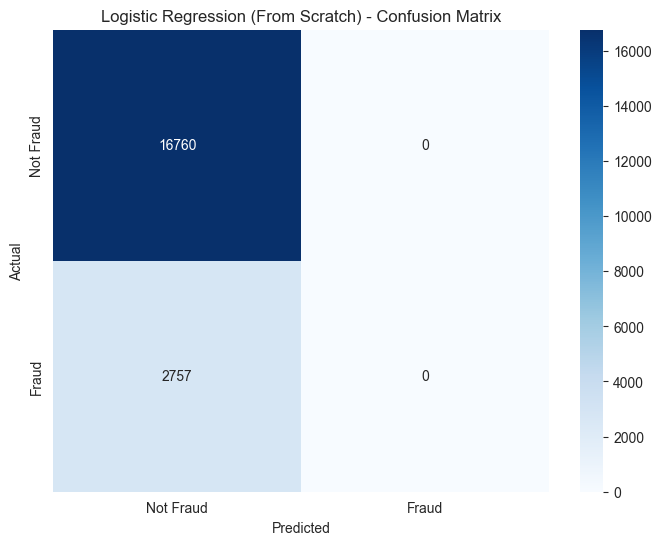

=== LOGISTIC REGRESSION (FROM SCRATCH) ===


Training Logistic Regression model from scratch...
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.590702
Iteration 100: Loss = 0.590702
Iteration 200: Loss = 0.527806
Iteration 200: Loss = 0.527806
Iteration 300: Loss = 0.488182
Iteration 300: Loss = 0.488182
Iteration 400: Loss = 0.462478
Iteration 400: Loss = 0.462478
Iteration 500: Loss = 0.445332
Iteration 500: Loss = 0.445332
Iteration 600: Loss = 0.433609
Iteration 600: Loss = 0.433609
Iteration 700: Loss = 0.425422
Iteration 700: Loss = 0.425422
Iteration 800: Loss = 0.419599
Iteration 800: Loss = 0.419599
Iteration 900: Loss = 0.415392
Iteration 900: Loss = 0.415392
Iteration 1000: Loss = 0.412311
Iteration 1000: Loss = 0.412311
Iteration 1100: Loss = 0.410030
Iteration 1100: Loss = 0.410030
Iteration 1200: Loss = 0.408323
Iteration 1200: Loss = 0.408323
Iteration 1300: Loss = 0.407034
Iteration 1300: Loss = 0.407034
Iteration 1400: Loss = 0.406055
Iteration 1400: Loss = 0.4060

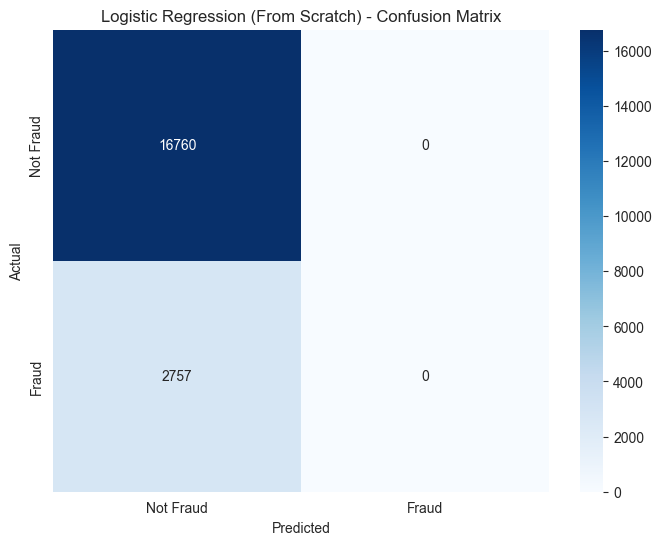

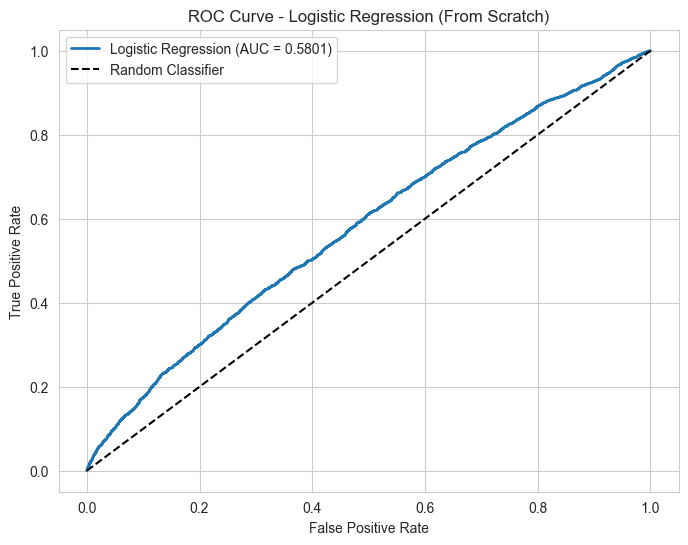

=== LOGISTIC REGRESSION (FROM SCRATCH) ===


Training Logistic Regression model from scratch...
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.590702
Iteration 100: Loss = 0.590702
Iteration 200: Loss = 0.527806
Iteration 200: Loss = 0.527806
Iteration 300: Loss = 0.488182
Iteration 300: Loss = 0.488182
Iteration 400: Loss = 0.462478
Iteration 400: Loss = 0.462478
Iteration 500: Loss = 0.445332
Iteration 500: Loss = 0.445332
Iteration 600: Loss = 0.433609
Iteration 600: Loss = 0.433609
Iteration 700: Loss = 0.425422
Iteration 700: Loss = 0.425422
Iteration 800: Loss = 0.419599
Iteration 800: Loss = 0.419599
Iteration 900: Loss = 0.415392
Iteration 900: Loss = 0.415392
Iteration 1000: Loss = 0.412311
Iteration 1000: Loss = 0.412311
Iteration 1100: Loss = 0.410030
Iteration 1100: Loss = 0.410030
Iteration 1200: Loss = 0.408323
Iteration 1200: Loss = 0.408323
Iteration 1300: Loss = 0.407034
Iteration 1300: Loss = 0.407034
Iteration 1400: Loss = 0.406055
Iteration 1400: Loss = 0.4060

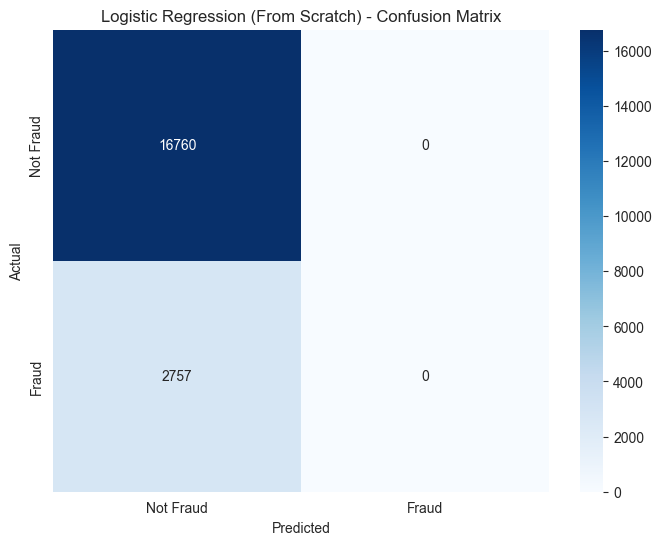

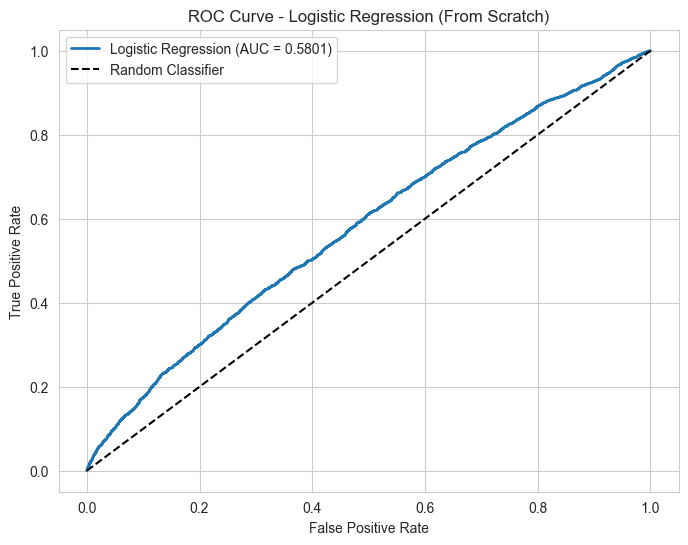

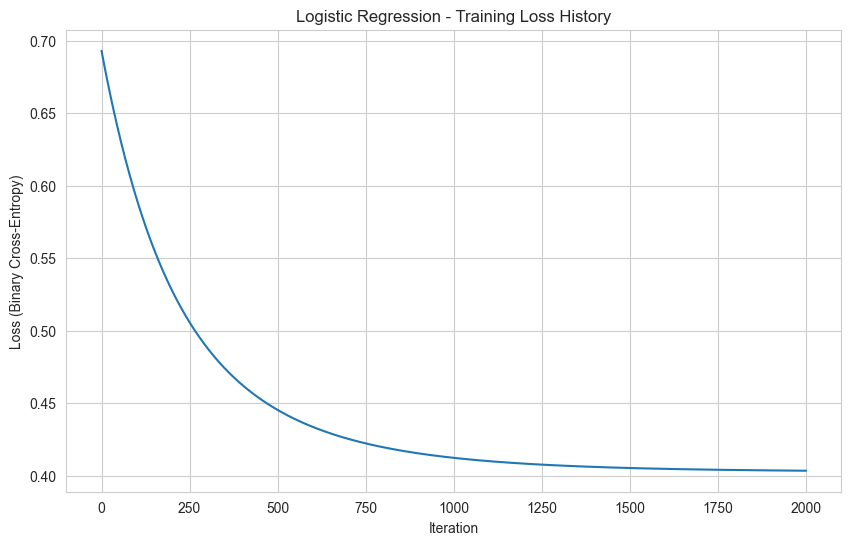


=== MODEL PARAMETERS ===
Number of weights: 23
Bias term: -1.717954
Final loss: 0.403447


In [ ]:
# Import custom Logistic Regression from algorithms folder (FROM SCRATCH)
import sys
sys.path.append('algorithms')
from logistic_regression import LogisticRegression

# Initialize custom Logistic Regression model
lr_model = LogisticRegression(
    learning_rate=0.01,
    n_iterations=2000,
    regularization='l2',
    lambda_reg=0.01,
    verbose=True
)

# Train the model
print("\nTraining Logistic Regression model from scratch...")
lr_model.fit(X_train_scaled, y_train)

# Make predictions on validation set
y_val_pred = lr_model.predict(X_val_scaled)
y_val_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]

# Calculate evaluation metrics manually (from scratch)
def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def calculate_precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0

def calculate_recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def calculate_f1_score(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

def calculate_confusion_matrix(y_true, y_pred):
    """Calculate confusion matrix"""
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

def calculate_roc_auc(y_true, y_pred_proba):
    # Sort by predicted probabilities
    sorted_indices = np.argsort(y_pred_proba)[::-1]
    y_true_sorted = y_true.values[sorted_indices]
    
    # Calculate TPR and FPR
    tpr = []
    fpr = []
    thresholds = np.unique(y_pred_proba)
    thresholds = np.sort(thresholds)[::-1]
    
    for threshold in thresholds:
        y_pred_temp = (y_pred_proba >= threshold).astype(int)
        tp = np.sum((y_true == 1) & (y_pred_temp == 1))
        fp = np.sum((y_true == 0) & (y_pred_temp == 1))
        tn = np.sum((y_true == 0) & (y_pred_temp == 0))
        fn = np.sum((y_true == 1) & (y_pred_temp == 0))
        
        tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        tpr.append(tpr_val)
        fpr.append(fpr_val)
    
    # Calculate AUC using trapezoidal rule
    tpr = np.array(tpr)
    fpr = np.array(fpr)
    sorted_indices = np.argsort(fpr)
    fpr = fpr[sorted_indices]
    tpr = tpr[sorted_indices]
    
    auc = 0
    for i in range(1, len(fpr)):
        auc += (fpr[i] - fpr[i-1]) * (tpr[i] + tpr[i-1]) / 2
    
    return auc, fpr, tpr

# Calculate metrics
lr_accuracy = calculate_accuracy(y_val, y_val_pred)
lr_precision = calculate_precision(y_val, y_val_pred)
lr_recall = calculate_recall(y_val, y_val_pred)
lr_f1 = calculate_f1_score(lr_precision, lr_recall)
lr_roc_auc, fpr, tpr = calculate_roc_auc(y_val, y_val_pred_proba)

print("\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")

# Confusion Matrix
print("\n=== CONFUSION MATRIX ===")
cm = calculate_confusion_matrix(y_val, y_val_pred)
print(cm)
print(f"\nTrue Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Logistic Regression (From Scratch) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (From Scratch)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training Loss History
plt.figure(figsize=(10, 6))
plt.plot(lr_model.loss_history)
plt.title('Logistic Regression - Training Loss History')
plt.xlabel('Iteration')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.grid(True)
plt.show()

# Display model coefficients summary
coefficients = lr_model.get_coefficients()
print("\n=== MODEL PARAMETERS ===")
print(f"Number of weights: {len(coefficients['weights'])}")
print(f"Bias term: {coefficients['bias']:.6f}")
print(f"Final loss: {lr_model.loss_history[-1]:.6f}")

## C. KNN

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [26]:
# Type your code here

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [27]:
# Type your code here

# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

`Provide your analysis here`